In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
from scipy.stats import norm
import yfinance as yf

In [ ]:
years = 15
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*years)
Tickers = ['SPY', 'BND', 'GLD','QQQ','VTI']

In [ ]:
adj_close_df =pd.DataFrame()
for ticker in Tickers:
  data = yf.download(ticker, start=startDate, end=endDate)
  adj_close_df[ticker] = data['Close']



/tmp/ipython-input-3294116843.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3294116843.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3294116843.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3294116843.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3294116843.py

In [ ]:
print(adj_close_df)

                   SPY        BND         GLD         QQQ         VTI
Date                                                                 
2011-02-22  100.849586  52.056221  136.289993   50.022568   52.318874
2011-02-23  100.229942  52.049686  137.509995   49.610336   51.880646
2011-02-24  100.161079  52.101788  136.479996   49.873482   51.888336
2011-02-25  101.232048  52.245026  137.380005   50.566418   52.541836
2011-02-28  101.859390  52.316628  137.660004   50.671661   52.826313
...                ...        ...         ...         ...         ...
2026-02-09  693.950012  74.250000  467.029999  614.320007  342.640015
2026-02-10  692.119995  74.470001  462.399994  611.469971  341.799988
2026-02-11  691.960022  74.320000  467.630005  613.109985  341.470001
2026-02-12  681.270020  74.660004  451.390015  600.640015  336.010010
2026-02-13  681.750000  74.879997  462.619995  601.919983  336.649994

[3768 rows x 5 columns]


In [ ]:
log_returns = np.log(adj_close_df/adj_close_df.shift(1))
log_returns = log_returns.dropna()

print(log_returns)

                 SPY       BND       GLD       QQQ       VTI
Date                                                        
2011-02-23 -0.006163 -0.000126  0.008912 -0.008275 -0.008411
2011-02-24 -0.000687  0.001000 -0.007519  0.005290  0.000148
2011-02-25  0.010636  0.002745  0.006573  0.013798  0.012516
2011-02-28  0.006178  0.001370  0.002036  0.002079  0.005400
2011-03-01 -0.016814 -0.000473  0.017070 -0.016230 -0.017027
...              ...       ...       ...       ...       ...
2026-02-09  0.004810  0.000269  0.025086  0.007631  0.004915
2026-02-10 -0.002641  0.002959 -0.009963 -0.004650 -0.002455
2026-02-11 -0.000231 -0.002016  0.011247  0.002678 -0.000966
2026-02-12 -0.015569  0.004564 -0.035346 -0.020549 -0.016119
2026-02-13  0.000704  0.002942  0.024574  0.002129  0.001903

[3767 rows x 5 columns]


In [ ]:
Portfolio_value = 100000
weights = np.array([1/len(Tickers)]*len(Tickers))
print(weights)

[0.2 0.2 0.2 0.2 0.2]


In [ ]:
historical_returns = (log_returns* weights).sum(axis=1)
print(historical_returns)

Date
2011-02-23   -0.002813
2011-02-24   -0.000353
2011-02-25    0.009254
2011-02-28    0.003412
2011-03-01   -0.006695
                ...   
2026-02-09    0.008542
2026-02-10   -0.003350
2026-02-11    0.002142
2026-02-12   -0.016604
2026-02-13    0.006450
Length: 3767, dtype: float64


In [ ]:
days = 5
range_returns = historical_returns.rolling(days).sum().dropna()
print(range_returns)

Date
2011-03-01    0.002805
2011-03-02    0.006955
2011-03-03    0.014807
2011-03-04    0.004171
2011-03-07   -0.004841
                ...   
2026-02-09    0.014640
2026-02-10    0.005244
2026-02-11    0.013048
2026-02-12    0.008981
2026-02-13   -0.002818
Length: 3763, dtype: float64


In [ ]:
confidence_interval = 0.95
significance_level = 0.05
Var = -np.percentile(range_returns, significance_level*100)*Portfolio_value
print(Var)

2358.9223362223033


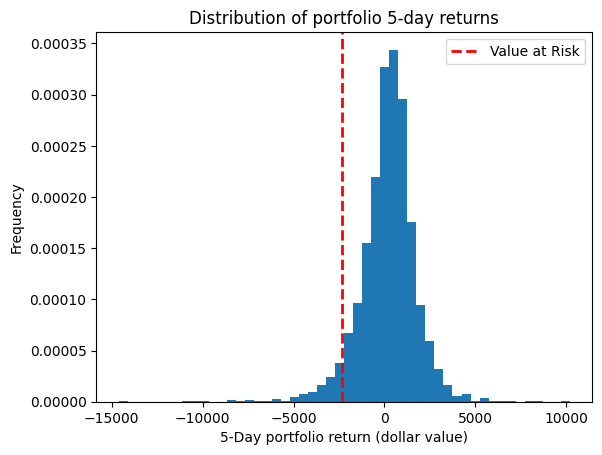

In [ ]:
return_window = days

range_returns = historical_returns.rolling(return_window).sum().dropna()

range_returns_dollar = range_returns * Portfolio_value

plt.hist(range_returns_dollar, bins=50, density=True)
plt.xlabel(f'{return_window}-Day portfolio return (dollar value)')
plt.ylabel('Frequency')
plt.title(f'Distribution of portfolio {return_window}-day returns')
plt.axvline(-Var, color='r', linestyle='dashed', linewidth=2, label='Value at Risk')
plt.legend()
plt.show()